# NAPL Product preferences, sentiment analysis, keywords analysis

## By B11001019傅煒宸, B11001137許庭瑄

In [2]:
import pymongo
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pymongo import MongoClient
from IPython.display import display #用於在 Notebook中更美觀地顯示DataFrame
from wordcloud import WordCloud
from collections import Counter
from sklearn.feature_extraction.text import TfidfVectorizer
import warnings
warnings.filterwarnings('ignore')

# Connect to MongoDB
client = MongoClient('mongodb://localhost:27017/')
db = client['mydatabase']

# Function to safely retrieve data in chunks
def get_data_in_chunks(collection, query={}, projection=None, chunk_size=10000):
    """Retrieve data from MongoDB in chunks to avoid memory issues"""
    total_docs = db[collection].count_documents(query)
    all_data = []
    
    for i in range(0, total_docs, chunk_size):
        chunk = list(db[collection].find(query, projection).skip(i).limit(chunk_size))
        all_data.extend(chunk)
        print(f"Retrieved {min(i + chunk_size, total_docs)}/{total_docs} documents")
    
    return pd.DataFrame(all_data)

# Get sample data for initial analysis (adjust projection as needed)
reviews_sample = get_data_in_chunks(
    "reviews", 
    projection={
        "ProductId": 1, "UserId": 1, "Score": 1, "Time": 1, 
        "Summary": 1, "Text": 1, "Sentiment_score": 1, 
        "Tokens": 1, "POS_tags": 1, "Named_entities": 1,
        "NAPL_Label": 1
    },
    chunk_size=50000  # Adjust based on your system memory
)

# Get product data
products = get_data_in_chunks(
    "products",
    projection={
        "_id": 1, "parent_asin": 1, "title": 1, "main_category": 1,
        "categories": 1, "average_rating": 1, "rating_number": 1
    }
)

Retrieved 50000/568454 documents
Retrieved 100000/568454 documents
Retrieved 150000/568454 documents
Retrieved 200000/568454 documents
Retrieved 250000/568454 documents
Retrieved 300000/568454 documents
Retrieved 350000/568454 documents
Retrieved 400000/568454 documents
Retrieved 450000/568454 documents
Retrieved 500000/568454 documents
Retrieved 550000/568454 documents
Retrieved 568454/568454 documents
Retrieved 10000/33817 documents
Retrieved 20000/33817 documents
Retrieved 30000/33817 documents
Retrieved 33817/33817 documents


Latest review date: 2012-10-26 00:00:00
Cutoff date (3 months prior): 2012-07-28 00:00:00

NAPL Customer Segmentation:
NAPL_Label
L    153199
P     66035
N     22192
A     14633
Name: count, dtype: int64


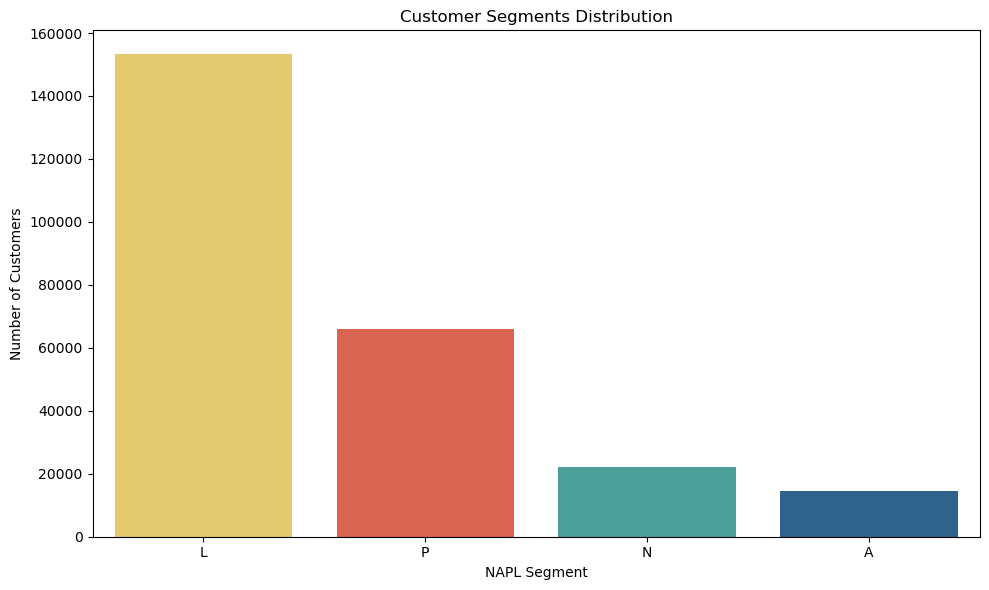

In [10]:
from datetime import datetime, timedelta

# 1. Convert Unix timestamp to datetime
reviews_sample['Time_converted'] = pd.to_datetime(reviews_sample['Time'], unit='s')

# 2. Find latest time and define cutoff for 3 months prior
latest_time = reviews_sample['Time_converted'].max()
cutoff_3_months = latest_time - timedelta(days=90)
print(f"Latest review date: {latest_time}")
print(f"Cutoff date (3 months prior): {cutoff_3_months}")

# 3. Create customer statistics
customer_stats = reviews_sample.groupby('UserId').agg(
    purchase_count=('Time_converted', 'count'),
    last_purchase=('Time_converted', 'max'),
    first_purchase=('Time_converted', 'min')
).reset_index()

# 4. Define NAPL classification function
def label_napl(row):
    if row['purchase_count'] == 1:
        if row['first_purchase'] >= cutoff_3_months:
            return 'N'  # New
        else:
            return 'L'  # Lost
    else:
        if row['last_purchase'] >= cutoff_3_months:
            return 'A'  # Active
        else:
            return 'P'  # Potential

# 5. Add NAPL_Label to customer stats
customer_stats['NAPL_Label'] = customer_stats.apply(label_napl, axis=1)

# 6. If NAPL_Label doesn't exist in reviews_sample, merge it
if 'NAPL_Label' not in reviews_sample.columns:
    reviews_sample = reviews_sample.merge(
        customer_stats[['UserId', 'NAPL_Label']], on='UserId', how='left'
    )

# 7. View customer segment counts
napl_counts = customer_stats['NAPL_Label'].value_counts()
print("\nNAPL Customer Segmentation:")
print(napl_counts)

# 自定義 NAPL 顏色
napl_palette = {
    'N': '#3CAEA3',     # New - 綠色
    'A': '#20639B',     # Active - 藍色
    'P': '#ED553B',     # Potential - 橘色
    'L': '#F6D55C'      # Lost - 黃色
}

# Plot NAPL distribution with custom colors
plt.figure(figsize=(10, 6))
sns.barplot(
    x=napl_counts.index, 
    y=napl_counts.values, 
    palette=[napl_palette[label] for label in napl_counts.index]
)
plt.title('Customer Segments Distribution')
plt.xlabel('NAPL Segment')
plt.ylabel('Number of Customers')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()


Top 5 Products for N Segment:
                                            title  Review_Count  Average_Score
0  Quaker Banana Nut Bread Soft Baked Bars - 5 CT           238       4.373950
1                                         Unknown           145       4.841379
2                                         Unknown           143       3.727273
3                                         Unknown           110       4.645455
4                                         Unknown            99       3.404040

Top 5 Products for A Segment:
                                               title  Review_Count  \
0  Chef Michael's Grilled Sirloin Dry Dog Food 4....           384   
1  Purina Beneful Dry Dog Food, Originals With Re...           369   
2  Essentia Water, Ionized and Alkaline Hydration...           358   
3  Essentia Bottled Water, 1 Liter, 12-Pack, Ioni...           358   
4                                            Unknown           358   

   Average_Score  
0       3.747396  
1    

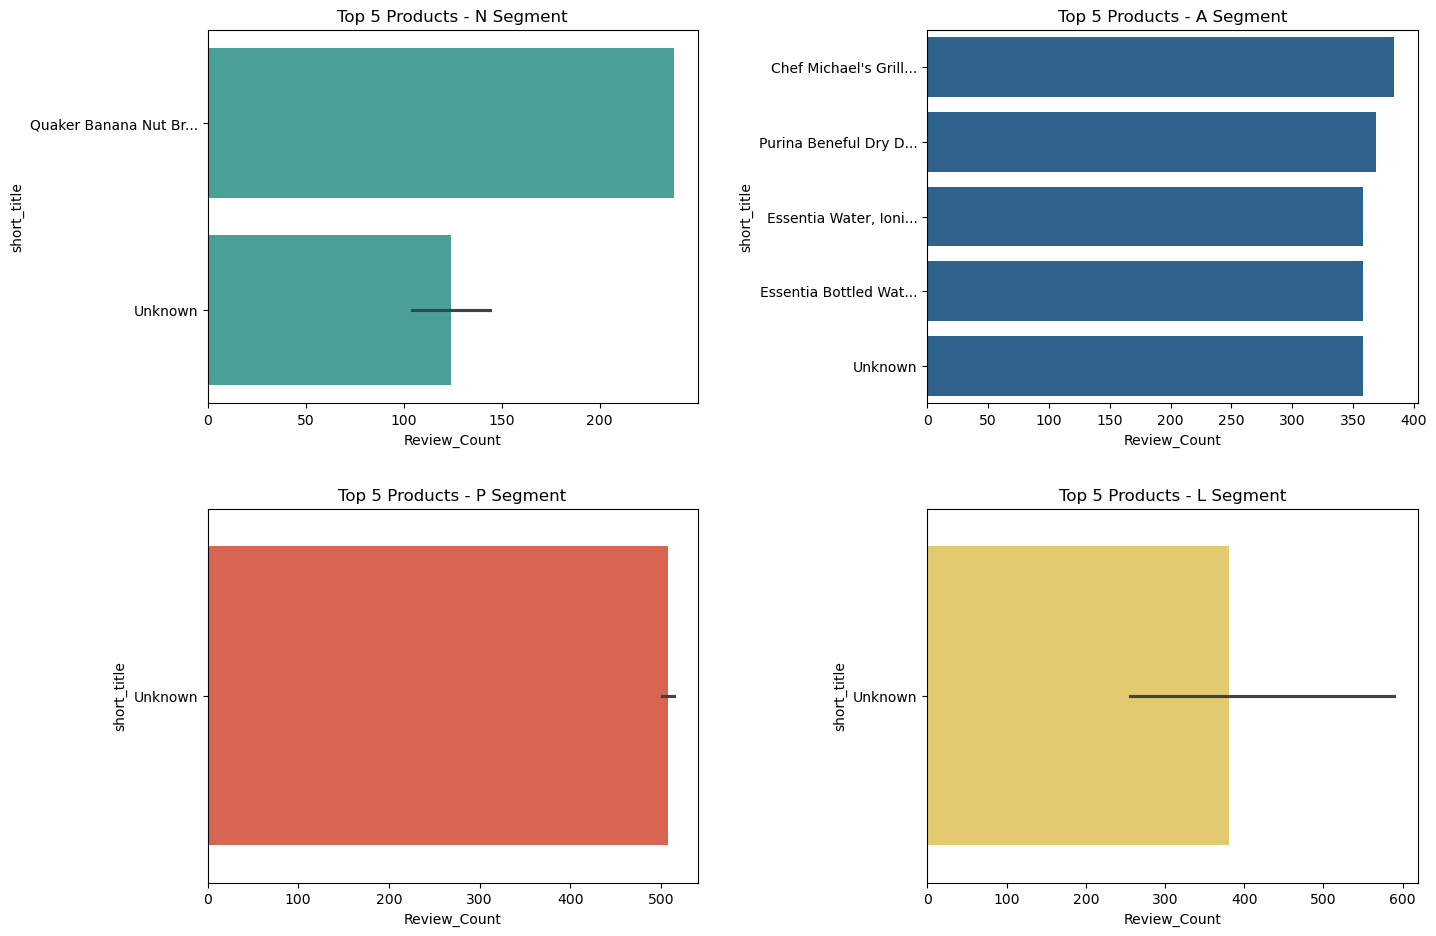

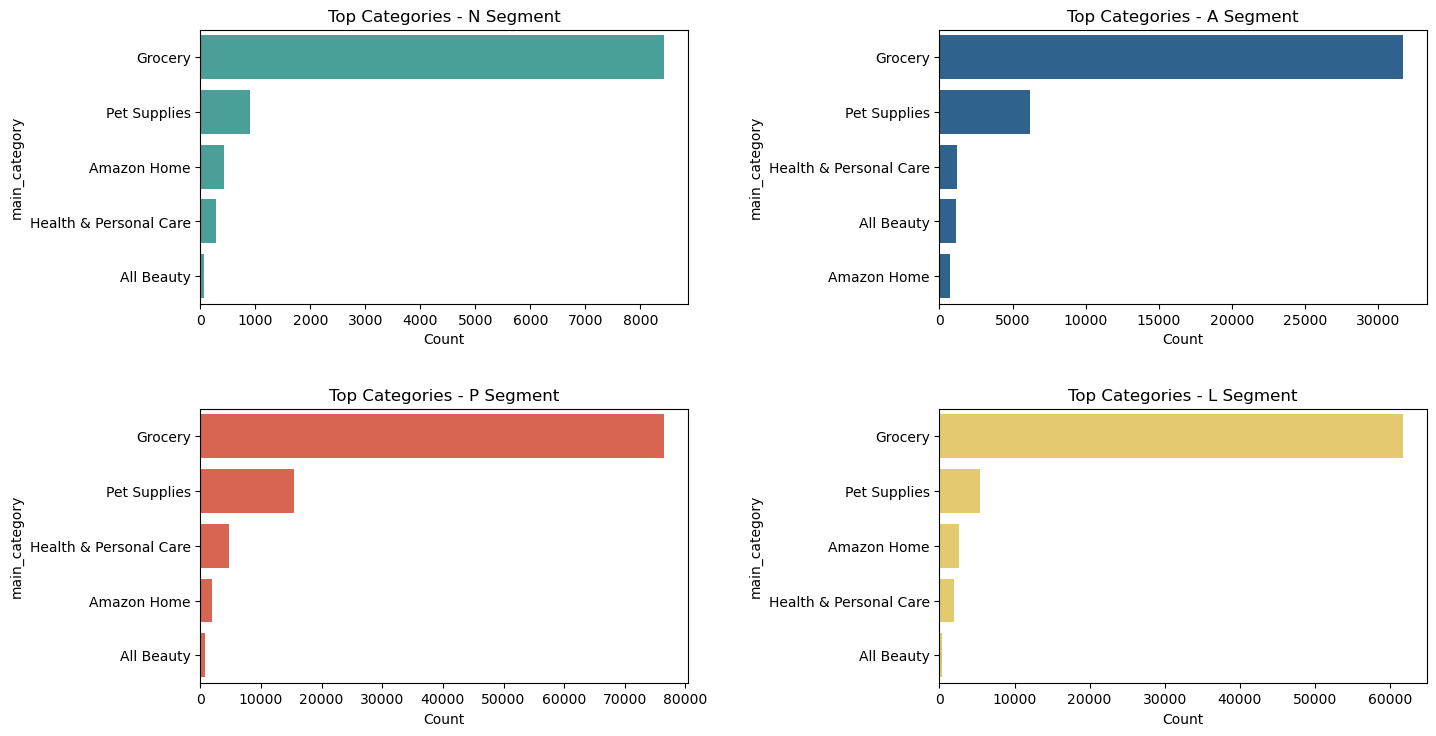

In [16]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Step 1. 確保 id 欄位為字串型別
products['_id'] = products['_id'].astype(str)
products['parent_asin'] = products['parent_asin'].astype(str)
reviews_sample['ProductId'] = reviews_sample['ProductId'].astype(str)

# Step 2. 將 reviews 與 products 透過 parent_asin 對應合併
merged_data = reviews_sample.merge(
    products[['parent_asin', 'title', 'main_category', 'categories', 'average_rating']],
    left_on='ProductId',
    right_on='parent_asin',
    how='left'
)

# Step 3. 定義分析函式
def analyze_top_products(data, segment=None, top_n=5):
    """Analyze top products for a specific NAPL segment or overall"""
    if segment:
        segment_data = data[data['NAPL_Label'] == segment]
    else:
        segment_data = data
    
    # Get top products by review count
    top_products = segment_data['ProductId'].value_counts().head(top_n)
    
    # Create DataFrame with product details
    top_product_details = pd.DataFrame({
        'ProductId': top_products.index,
        'Review_Count': top_products.values
    })
    
    # Add product title and average score
    product_scores = segment_data.groupby('ProductId')['Score'].mean().reset_index()
    product_titles = segment_data[['ProductId', 'title']].drop_duplicates()
    
    top_product_details = top_product_details.merge(
        product_scores, on='ProductId', how='left'
    ).merge(
        product_titles, on='ProductId', how='left'
    )
    
    top_product_details = top_product_details.rename(
        columns={'Score': 'Average_Score'}
    )
    
    # 確保 title 欄位不含 NaN 值並轉換為字符串
    top_product_details['title'] = top_product_details['title'].fillna('Unknown').astype(str)
    
    return top_product_details

# Step 4. 分析各 NAPL 區段的前五名產品
segments = ['N', 'A', 'P', 'L']
segment_top_products = {}

for segment in segments:
    segment_top_products[segment] = analyze_top_products(merged_data, segment)
    print(f"\nTop 5 Products for {segment} Segment:")
    print(segment_top_products[segment][['title', 'Review_Count', 'Average_Score']])

# Step 5. 可視化每個區段前五產品
plt.figure(figsize=(15, 10))
for i, segment in enumerate(segments):
    plt.subplot(2, 2, i+1)

    # Get data for this segment
    segment_data = segment_top_products[segment]
    
    # 縮短產品名稱以避免畫面擁擠
    short_titles = [str(title)[:20] + '...' if len(str(title)) > 20 else str(title) 
                   for title in segment_data['title']]
    
    # 建立繪圖資料
    plot_data = segment_data.copy()
    plot_data['short_title'] = short_titles
    
    sns.barplot(
        x='Review_Count', 
        y='short_title', 
        data=plot_data, 
        color=napl_palette[segment]
    )
    plt.title(f'Top 5 Products - {segment} Segment')
    plt.tight_layout()

plt.tight_layout(pad=3.0)
plt.show()

# Step 6. 可視化每個區段的主分類分布
plt.figure(figsize=(15, 8))
for i, segment in enumerate(segments):
    segment_data = merged_data[merged_data['NAPL_Label'] == segment]
    
    # 處理缺漏分類
    segment_data = segment_data[segment_data['main_category'].notna()]
    
    top_categories = segment_data['main_category'].value_counts().head(5)
    
    plt.subplot(2, 2, i+1)
    sns.barplot(
        x=top_categories.values, 
        y=top_categories.index, 
        color=napl_palette[segment]
    )
    plt.title(f'Top Categories - {segment} Segment')
    plt.xlabel('Count')
    plt.tight_layout()

plt.tight_layout(pad=3.0)
plt.show()


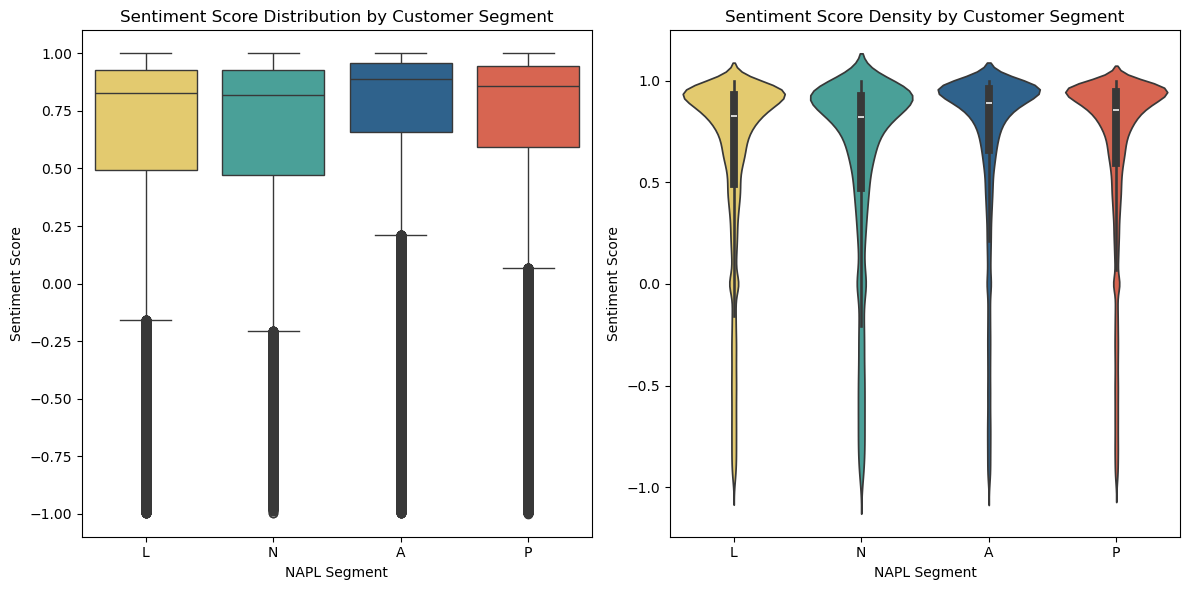


Sentiment Score Statistics by Segment:
  NAPL_Label      mean       std   count
0          A  0.691007  0.450947  103981
1          L  0.608156  0.484153  153199
2          N  0.590893  0.499527   22192
3          P  0.656687  0.457287  289082

Generating wordclouds for N segment...


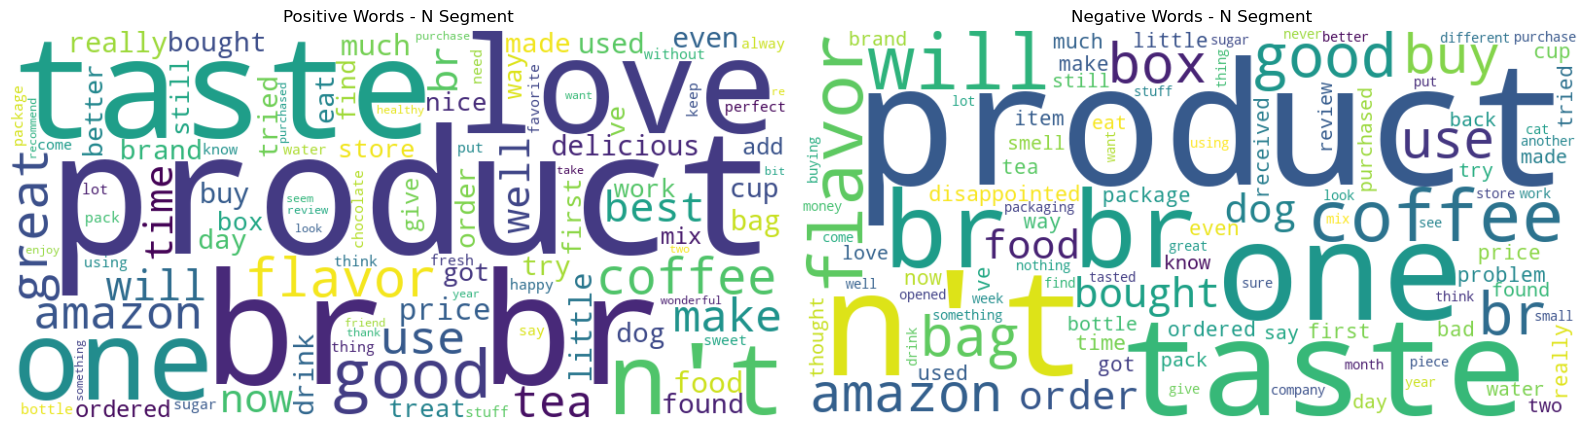


Generating wordclouds for A segment...


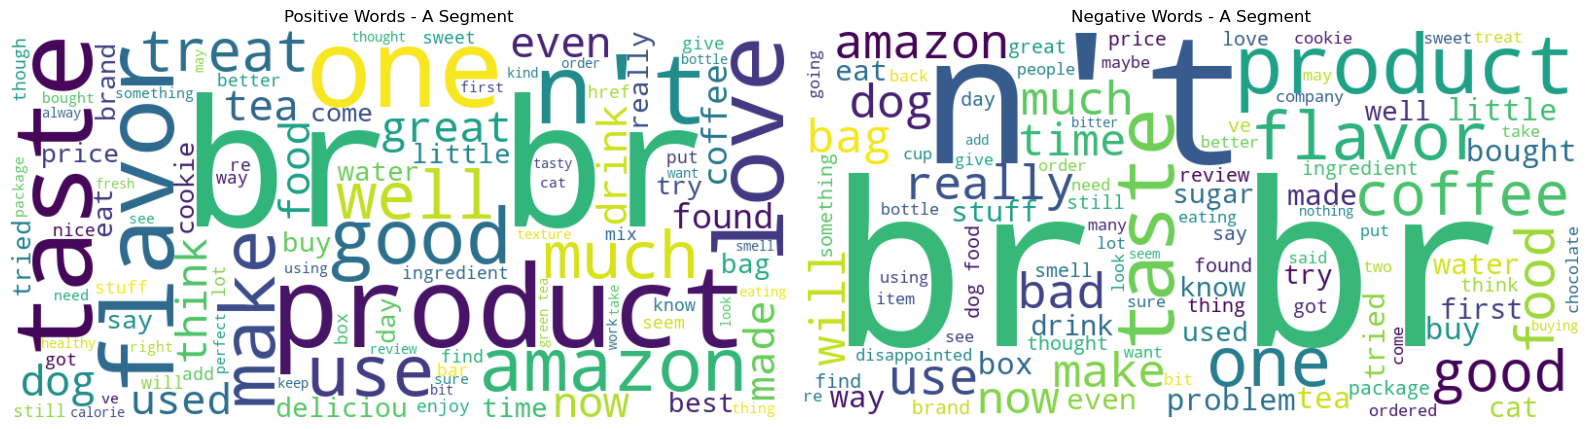


Generating wordclouds for P segment...


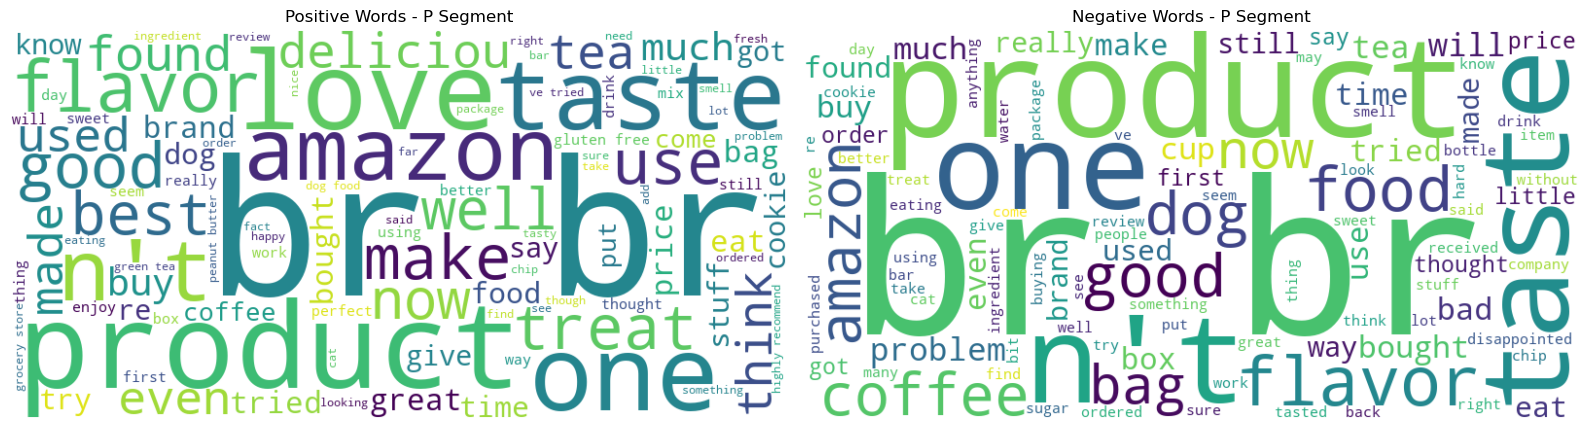


Generating wordclouds for L segment...


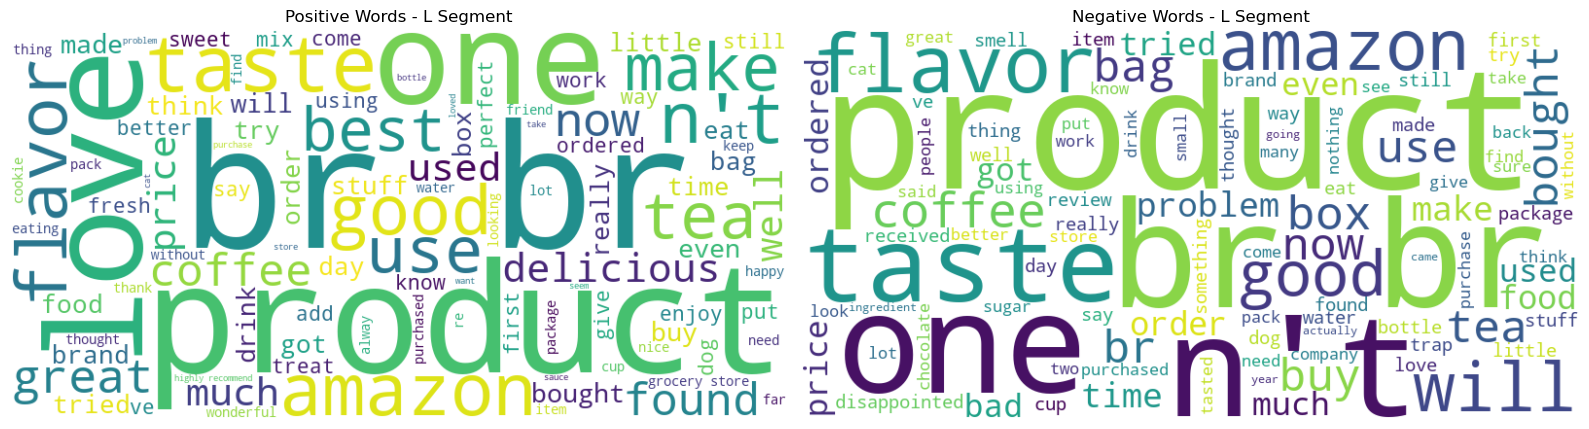

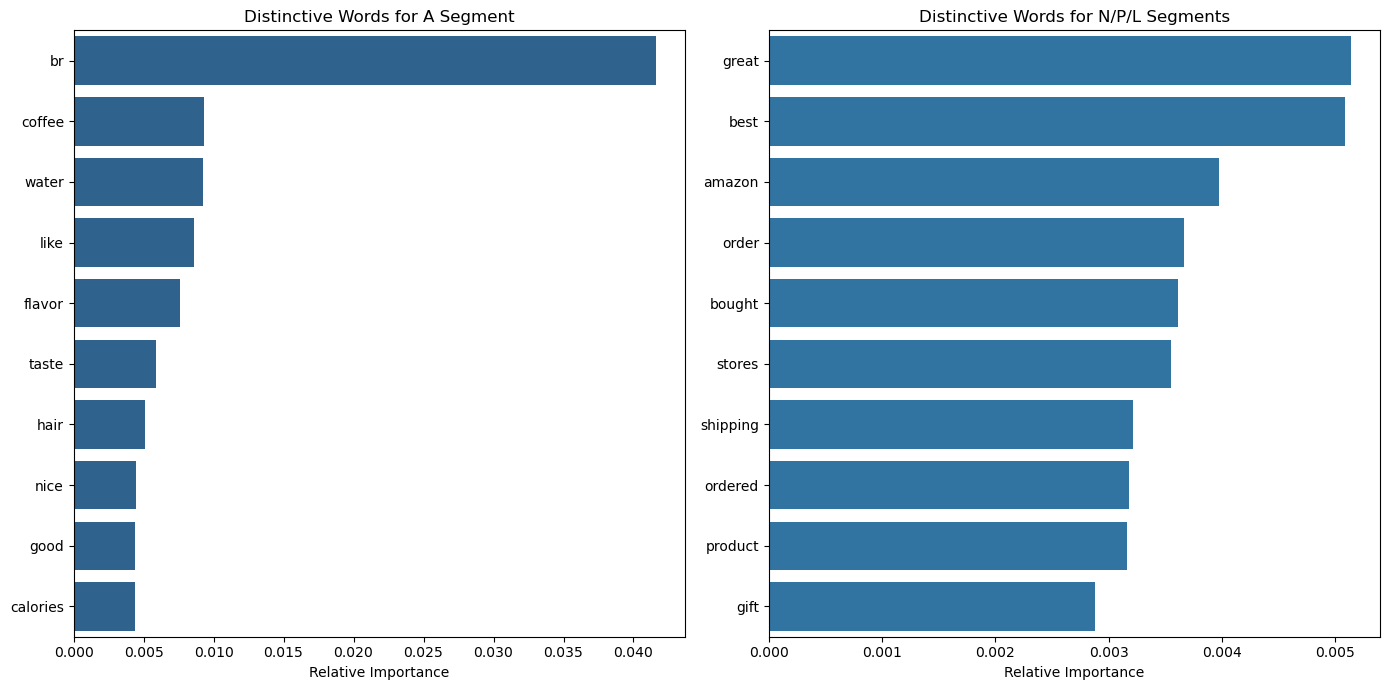

In [20]:
napl_palette = {
    'N': '#3CAEA3',     # New - 綠色
    'A': '#20639B',     # Active - 藍色
    'P': '#ED553B',     # Potential - 橘色
    'L': '#F6D55C'      # Lost - 黃色
}
## Model 2 Sentiment Score Analysis by NAPL Segment
plt.figure(figsize=(12, 6))

# Box plot of sentiment scores
plt.subplot(1, 2, 1)
sns.boxplot(x='NAPL_Label', y='Sentiment_score', data=merged_data, palette=napl_palette)
plt.title('Sentiment Score Distribution by Customer Segment')
plt.xlabel('NAPL Segment')
plt.ylabel('Sentiment Score')

# Violin plot of sentiment scores
plt.subplot(1, 2, 2)
sns.violinplot(x='NAPL_Label', y='Sentiment_score', data=merged_data, palette=napl_palette)
plt.title('Sentiment Score Density by Customer Segment')
plt.xlabel('NAPL Segment')
plt.ylabel('Sentiment Score')

plt.tight_layout()
plt.show()

# Calculate sentiment statistics by segment
sentiment_stats = merged_data.groupby('NAPL_Label')['Sentiment_score'].agg(['mean', 'std', 'count']).reset_index()
print("\nSentiment Score Statistics by Segment:")
print(sentiment_stats)

# Generate wordclouds for each segment (positive and negative reviews)
def generate_segment_wordclouds(data, segment):
    """Generate wordclouds for positive and negative reviews within a segment"""
    segment_data = data[data['NAPL_Label'] == segment]
    
    # Define positive and negative reviews based on sentiment score
    positive_reviews = segment_data[segment_data['Sentiment_score'] > 0.5]
    negative_reviews = segment_data[segment_data['Sentiment_score'] < 0]
    
    # Function to extract words from token lists
    def get_tokens_text(reviews_df):
        all_tokens = []
        for tokens in reviews_df['Tokens'].dropna():
            if isinstance(tokens, list):
                all_tokens.extend([t.lower() for t in tokens if len(t) > 2])
        return ' '.join(all_tokens)
    
    # Generate and plot wordclouds
    plt.figure(figsize=(16, 8))
    
    # Positive wordcloud
    plt.subplot(1, 2, 1)
    pos_text = get_tokens_text(positive_reviews)
    if pos_text:
        wordcloud_pos = WordCloud(width=800, height=400, 
                                 background_color='white', 
                                 max_words=100).generate(pos_text)
        plt.imshow(wordcloud_pos, interpolation='bilinear')
        plt.title(f'Positive Words - {segment} Segment')
        plt.axis('off')
    else:
        plt.text(0.5, 0.5, 'No positive reviews found', 
                 horizontalalignment='center', verticalalignment='center')
        plt.axis('off')
    
    # Negative wordcloud
    plt.subplot(1, 2, 2)
    neg_text = get_tokens_text(negative_reviews)
    if neg_text:
        wordcloud_neg = WordCloud(width=800, height=400, 
                                 background_color='white', 
                                 max_words=100).generate(neg_text)
        plt.imshow(wordcloud_neg, interpolation='bilinear')
        plt.title(f'Negative Words - {segment} Segment')
        plt.axis('off')
    else:
        plt.text(0.5, 0.5, 'No negative reviews found', 
                 horizontalalignment='center', verticalalignment='center')
        plt.axis('off')
    
    plt.tight_layout()
    plt.show()

# Generate wordclouds for each segment
for segment in segments:
    print(f"\nGenerating wordclouds for {segment} segment...")
    generate_segment_wordclouds(merged_data, segment)

# TF-IDF Analysis to find distinctive words between A segment and others
def tfidf_segment_comparison(data, segment_a='A', segments_other=['N', 'P', 'L'], top_n=10):
    """Compare TF-IDF vectors to find distinctive words between segments"""
    # Prepare documents for each segment
    a_docs = []
    other_docs = []
    
    # Get all tokens for segment A
    for tokens in data[data['NAPL_Label'] == segment_a]['Tokens']:
        if isinstance(tokens, list):
            a_docs.append(' '.join([t.lower() for t in tokens if len(t) > 2]))
    
    # Get all tokens for other segments
    for segment in segments_other:
        for tokens in data[data['NAPL_Label'] == segment]['Tokens']:
            if isinstance(tokens, list):
                other_docs.append(' '.join([t.lower() for t in tokens if len(t) > 2]))
    
    # Combine all documents
    all_docs = a_docs + other_docs
    
    # Create labels for the documents
    labels = ['A'] * len(a_docs) + ['Other'] * len(other_docs)
    
    # Create TF-IDF vectors
    vectorizer = TfidfVectorizer(max_features=1000, stop_words='english')
    tfidf_matrix = vectorizer.fit_transform(all_docs)
    
    # Get feature names
    feature_names = vectorizer.get_feature_names_out()
    
    # Calculate average TF-IDF for each segment
    a_tfidf = tfidf_matrix[:len(a_docs)].mean(axis=0)
    other_tfidf = tfidf_matrix[len(a_docs):].mean(axis=0)
    
    # Convert to arrays and calculate difference
    a_tfidf = np.asarray(a_tfidf).flatten()
    other_tfidf = np.asarray(other_tfidf).flatten()
    
    # Find words that are more distinctive for A compared to others
    diff_tfidf = a_tfidf - other_tfidf
    
    # Get top words for A segment
    top_indices = diff_tfidf.argsort()[-top_n:][::-1]
    top_a_words = [(feature_names[i], diff_tfidf[i]) for i in top_indices]
    
    # Get top words for other segments
    bottom_indices = diff_tfidf.argsort()[:top_n]
    top_other_words = [(feature_names[i], -diff_tfidf[i]) for i in bottom_indices]
    
    return top_a_words, top_other_words

# Run TF-IDF comparison
top_a_words, top_other_words = tfidf_segment_comparison(merged_data)

# Visualize distinctive words
plt.figure(figsize=(14, 7))

# A segment distinctive words
plt.subplot(1, 2, 1)
words, scores = zip(*top_a_words)
sns.barplot(x=list(scores), y=list(words), color=napl_palette['A'])  # A segment 用橘色
plt.title('Distinctive Words for A Segment')
plt.xlabel('Relative Importance')

# Other segments distinctive words
plt.subplot(1, 2, 2)
words, scores = zip(*top_other_words)
sns.barplot(x=list(scores), y=list(words))
plt.title('Distinctive Words for N/P/L Segments')
plt.xlabel('Relative Importance')

plt.tight_layout()
plt.show()


Average Review Length by Segment:
  NAPL_Label  Text_Length  Token_Count
0          A   566.703561   122.122782
1          L   366.320942    79.920894
2          N   359.609319    78.378335
3          P   432.214157    94.091445


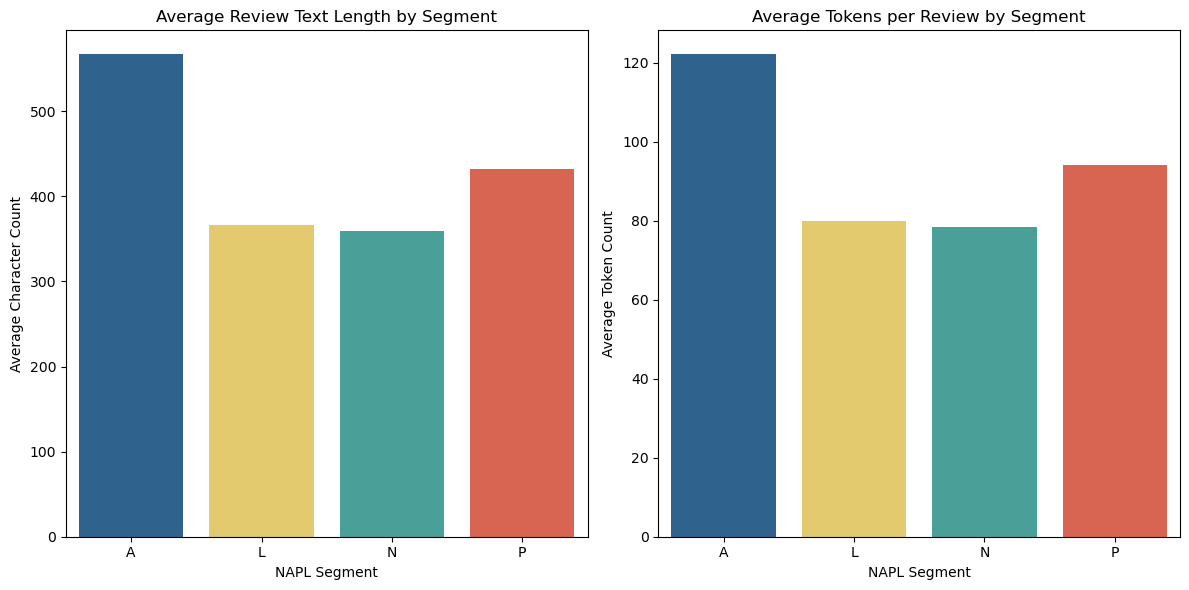


Top POS Tags for N Segment:
{'NOUN': 269772, 'VERB': 156329, 'ADJ': 111474, 'PROPN': 45671, 'ADV': 32224, 'SPACE': 31743, 'NUM': 15669, 'PUNCT': 10737, 'X': 5981, 'ADP': 4981}

Top POS Tags for A Segment:
{'NOUN': 2047329, 'VERB': 1048413, 'ADJ': 841779, 'PROPN': 367475, 'ADV': 230504, 'SPACE': 215951, 'PUNCT': 152215, 'NUM': 114182, 'X': 70690, 'ADP': 42148}

Top POS Tags for P Segment:
{'NOUN': 4276110, 'VERB': 2318596, 'ADJ': 1799831, 'PROPN': 764420, 'SPACE': 501627, 'ADV': 497320, 'NUM': 237740, 'PUNCT': 225072, 'X': 104526, 'ADP': 82764}

Top POS Tags for L Segment:
{'NOUN': 1893109, 'VERB': 1085634, 'ADJ': 785062, 'PROPN': 336682, 'SPACE': 240643, 'ADV': 227029, 'NUM': 108951, 'PUNCT': 78938, 'X': 41350, 'ADP': 34498}


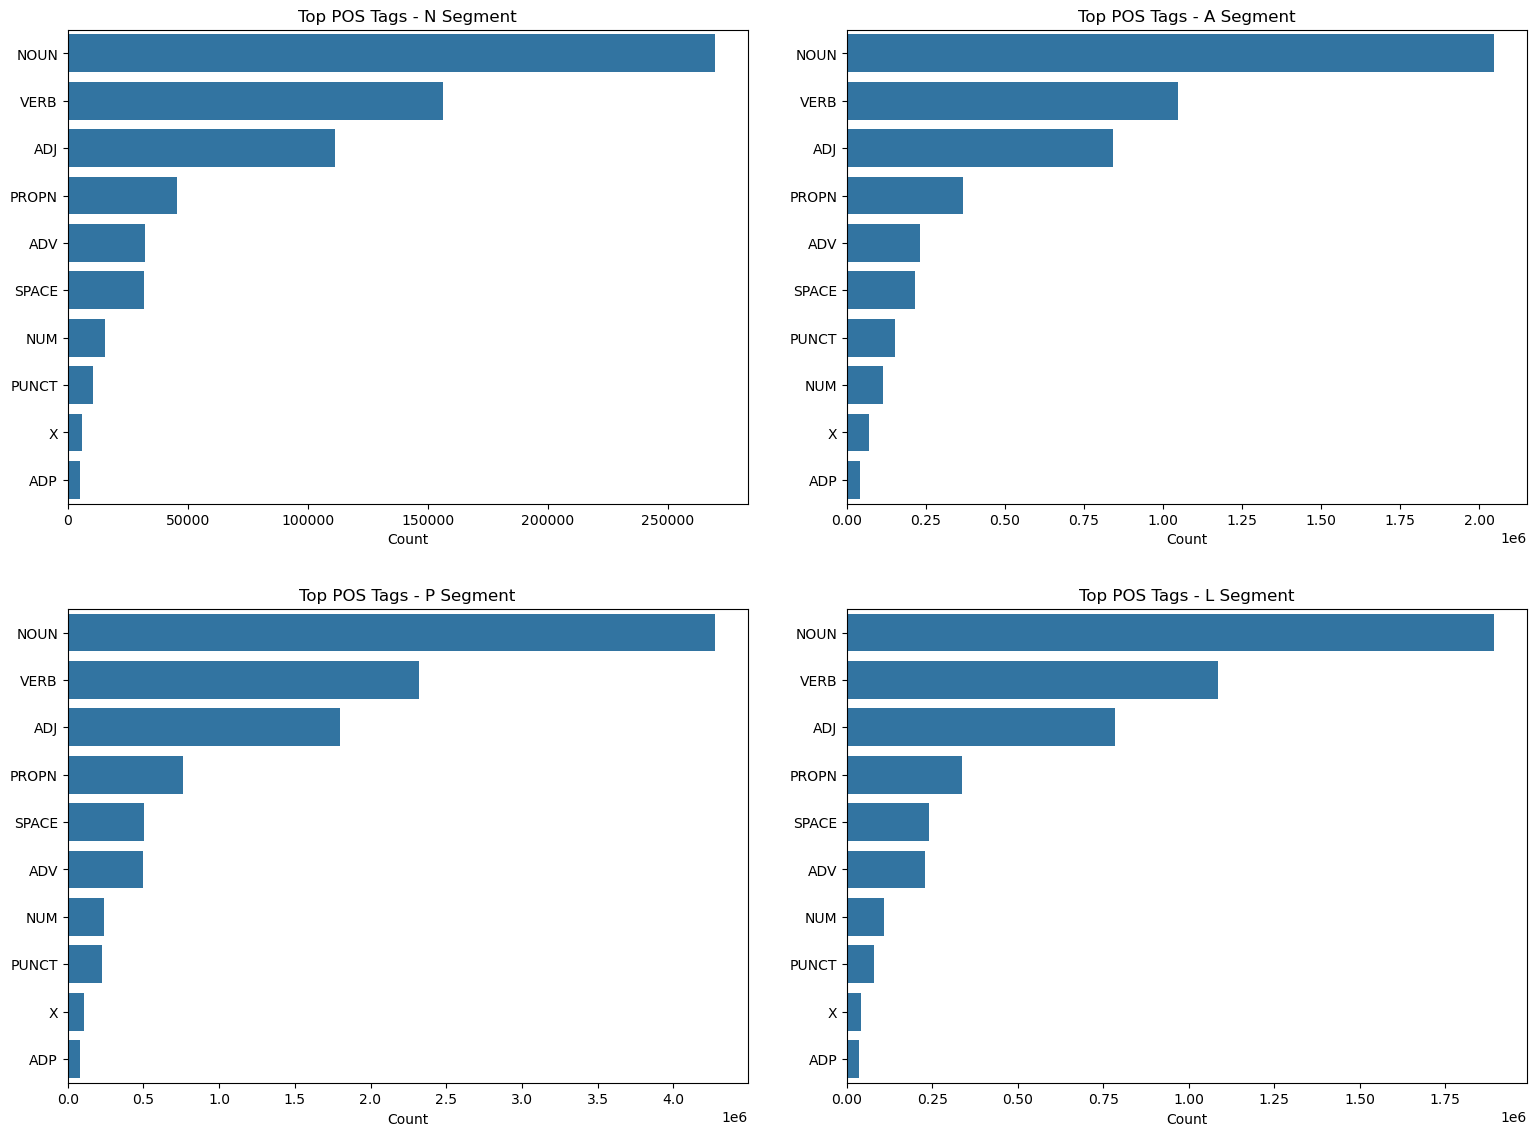


Named Entity Types for N Segment:
Counter({'ORG': 10242, 'CARDINAL': 9896, 'PRODUCT': 8300, 'DATE': 7975, 'QUANTITY': 3774, 'GPE': 2687, 'ORDINAL': 2450, 'TIME': 2364, 'MONEY': 2076, 'NORP': 1375, 'PERSON': 1186, 'PERCENT': 497, 'LOC': 377, 'FAC': 124, 'WORK_OF_ART': 120, 'EVENT': 50, 'LANGUAGE': 25, 'LAW': 16})

Named Entity Types for A Segment:
Counter({'CARDINAL': 69813, 'PRODUCT': 69194, 'ORG': 67381, 'DATE': 40194, 'QUANTITY': 36110, 'ORDINAL': 16293, 'TIME': 15684, 'GPE': 10402, 'PERSON': 9931, 'MONEY': 9394, 'NORP': 9214, 'PERCENT': 7117, 'LOC': 1971, 'WORK_OF_ART': 892, 'FAC': 585, 'EVENT': 239, 'LANGUAGE': 143, 'LAW': 83})

Named Entity Types for P Segment:
Counter({'ORG': 157374, 'CARDINAL': 150010, 'PRODUCT': 148804, 'DATE': 110983, 'QUANTITY': 62811, 'ORDINAL': 37843, 'TIME': 37285, 'GPE': 24582, 'MONEY': 23773, 'PERSON': 22700, 'NORP': 17500, 'PERCENT': 11243, 'LOC': 3969, 'WORK_OF_ART': 3014, 'FAC': 1254, 'EVENT': 567, 'LANGUAGE': 430, 'LAW': 147})

Named Entity Types fo

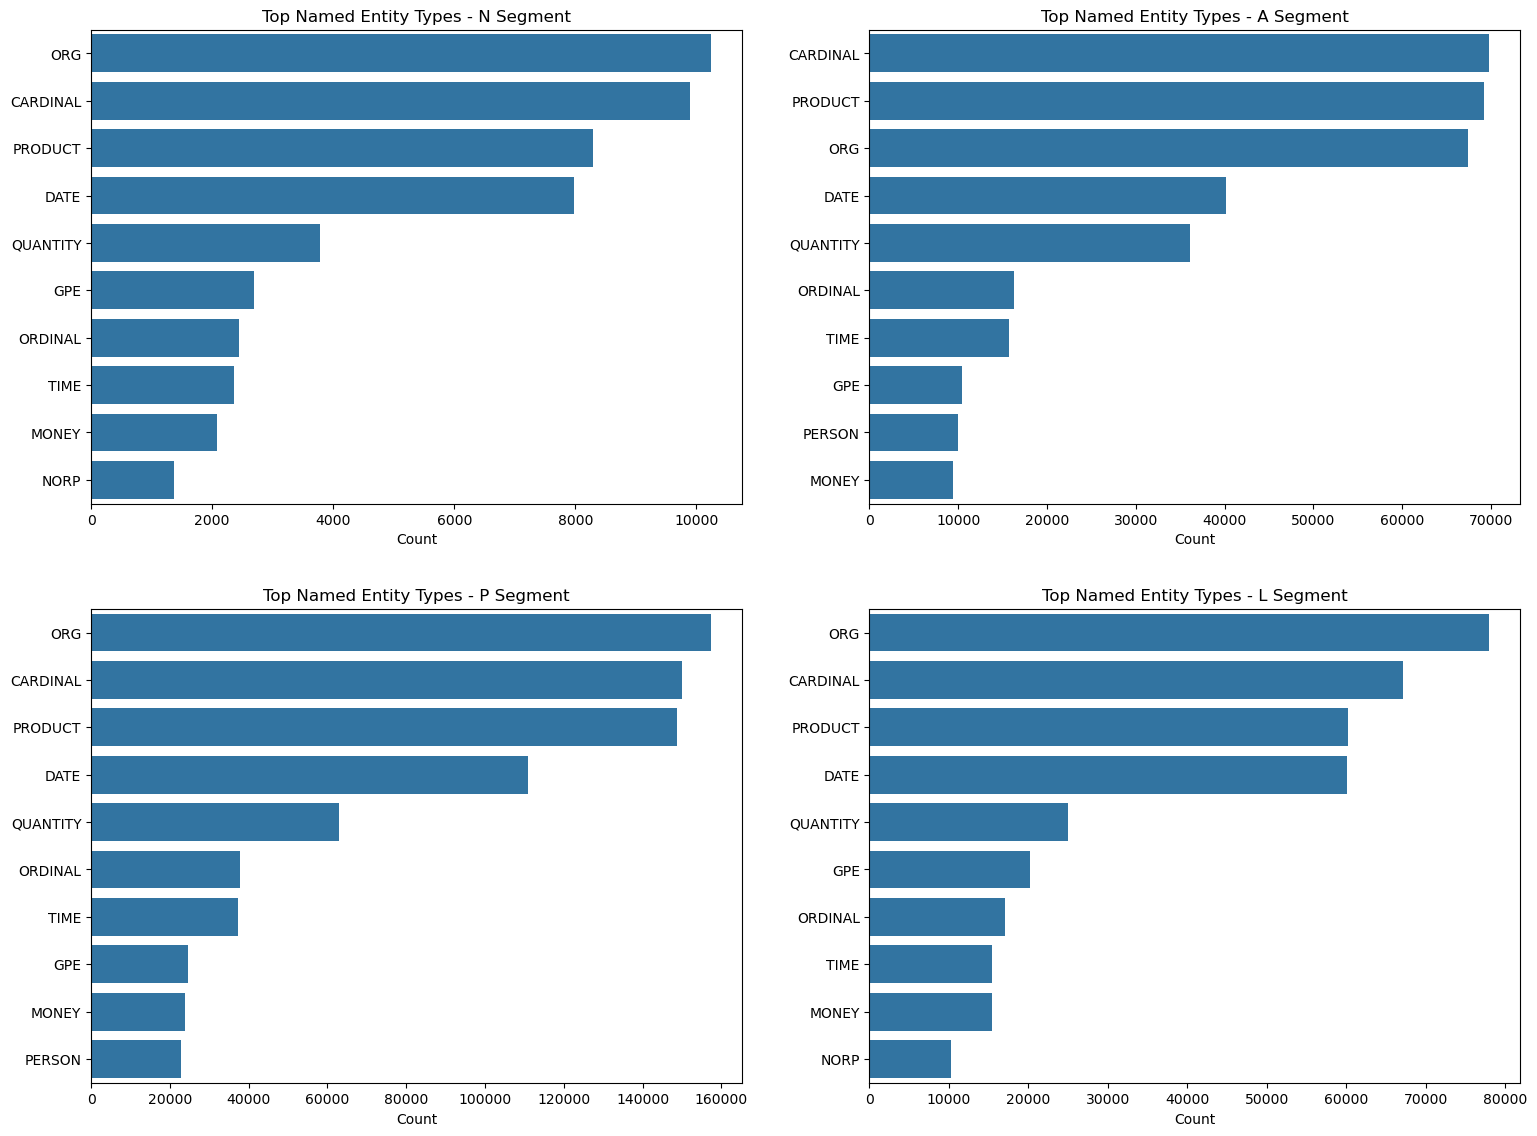

In [22]:
# Calculate average review length by segment
merged_data['Text_Length'] = merged_data['Text'].apply(lambda x: len(x) if isinstance(x, str) else 0)
merged_data['Token_Count'] = merged_data['Tokens'].apply(lambda x: len(x) if isinstance(x, list) else 0)

# Average text length by segment
text_length_stats = merged_data.groupby('NAPL_Label')[['Text_Length', 'Token_Count']].mean().reset_index()
print("\nAverage Review Length by Segment:")
print(text_length_stats)

# Visualize text length
plt.figure(figsize=(12, 6))

# Text length
plt.subplot(1, 2, 1)
sns.barplot(x='NAPL_Label', y='Text_Length', data=text_length_stats, palette=napl_palette)
plt.title('Average Review Text Length by Segment')
plt.xlabel('NAPL Segment')
plt.ylabel('Average Character Count')

# Token count
plt.subplot(1, 2, 2)
sns.barplot(x='NAPL_Label', y='Token_Count', data=text_length_stats, palette=napl_palette)
plt.title('Average Tokens per Review by Segment')
plt.xlabel('NAPL Segment')
plt.ylabel('Average Token Count')

plt.tight_layout()
plt.show()

# POS Tag Analysis
def analyze_pos_tags(data, segment=None):
    """Analyze POS tag distribution for a specific segment or overall"""
    if segment:
        segment_data = data[data['NAPL_Label'] == segment]
    else:
        segment_data = data
    
    # Extract all POS tags
    all_pos_tags = []
    for pos_tags in segment_data['POS_tags'].dropna():
        if isinstance(pos_tags, list):
            for tag_pair in pos_tags:
                if isinstance(tag_pair, list) and len(tag_pair) >= 2:
                    all_pos_tags.append(tag_pair[1])  # The tag is the second element
    
    # Count POS tags
    pos_counts = Counter(all_pos_tags)
    
    # Keep only the top 10 most common tags
    top_pos = dict(pos_counts.most_common(10))
    
    return top_pos

# Analyze POS tags for each segment
segment_pos_tags = {}
for segment in segments:
    segment_pos_tags[segment] = analyze_pos_tags(merged_data, segment)
    print(f"\nTop POS Tags for {segment} Segment:")
    print(segment_pos_tags[segment])

# Visualize POS tag distribution
plt.figure(figsize=(16, 12))
for i, segment in enumerate(segments):
    plt.subplot(2, 2, i+1)
    
    # Get data for this segment
    pos_data = segment_pos_tags[segment]
    
    # Plot
    sns.barplot(x=list(pos_data.values()), y=list(pos_data.keys()))
    plt.title(f'Top POS Tags - {segment} Segment')
    plt.xlabel('Count')
    plt.tight_layout()

plt.tight_layout(pad=3.0)
plt.show()

# Named Entity Analysis
def analyze_named_entities(data, segment=None):
    """Analyze named entity distribution for a specific segment or overall"""
    if segment:
        segment_data = data[data['NAPL_Label'] == segment]
    else:
        segment_data = data
    
    # Extract all named entities
    entity_types = []
    for entities in segment_data['Named_entities'].dropna():
        if isinstance(entities, list):
            for entity in entities:
                if isinstance(entity, list) and len(entity) >= 2:
                    entity_types.append(entity[1])  # The entity type is the second element
    
    # Count entity types
    entity_counts = Counter(entity_types)
    
    return entity_counts

# Analyze named entities for each segment
segment_entities = {}
for segment in segments:
    segment_entities[segment] = analyze_named_entities(merged_data, segment)
    print(f"\nNamed Entity Types for {segment} Segment:")
    print(segment_entities[segment])

# Visualize named entity distribution
plt.figure(figsize=(16, 12))
for i, segment in enumerate(segments):
    plt.subplot(2, 2, i+1)
    
    # Get data for this segment
    entity_data = segment_entities[segment]
    
    # Get the top 10 entity types
    top_entities = dict(entity_data.most_common(10))
    
    # Plot
    sns.barplot(x=list(top_entities.values()), y=list(top_entities.keys()))
    plt.title(f'Top Named Entity Types - {segment} Segment')
    plt.xlabel('Count')
    plt.tight_layout()

plt.tight_layout(pad=3.0)
plt.show()